## 🚀 ELEVVO INTERNSHIP | Abhisek Barik
### 📰 Topic Modeling on News Articles
### 🌟 Level-2 --> NLP Task 5 ✅ + Bonus💡Completed

In [2]:
# Install Required Libraries
!pip install gensim pyLDAvis nltk --quiet

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import nltk
import re
import gensim
import pyLDAvis
import pyLDAvis.gensim_models
import gensim.corpora as corpora
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import LdaModel
from pprint import pprint

In [4]:
# Download NLTK Resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 🔍Discover hidden topics or themes in a collection of news articles or blog posts📚

### 📝Dataset: BBC News📺

In [7]:
# Load Dataset
df = pd.read_csv("C:/Users/HP/Downloads/Elevvo NLP Internship/BBCNews.csv")  
df = df.dropna(subset=['descr'])  # Drop rows with empty descriptions
df.head()

,Unnamed: 0,descr,tags
0,0,chelsea sack mutu chelsea have sacked adrian ...,"sports, stamford bridge, football association,..."
1,1,record fails to lift lacklustre meet yelena i...,"sports, madrid, birmingham, france, scotland, ..."
2,2,edu describes tunnel fracas arsenals edu has ...,"sports, derby, brazil, tunnel fracasedu, food,..."
3,3,ogara revels in ireland victory ireland flyha...,"sports, bbc, united kingdom, ireland, brian o'..."
4,4,unclear future for striker baros liverpool fo...,"sports, liverpool, daily sport, millennium sta..."


## 🛠️Preprocess the text: Tokenization✂️, Lowercasing🔡, Stopword Removal🛑 

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = re.sub(r'\W', ' ', str(text))  # Remove special characters
    text = text.lower()                   # Lowercase
    tokens = nltk.word_tokenize(text)     # Tokenization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 3]
    return tokens

processed_docs = df['descr'].apply(preprocess)

In [10]:
# Create Dictionary and Corpus (needed for LDA)
id2word = corpora.Dictionary(processed_docs)                 # Map of word <-> ID
corpus = [id2word.doc2bow(text) for text in processed_docs]  # Convert to Bag of Words

## 📊Apply Latent Dirichlet Allocation (LDA) to extract dominant topics🧠

In [12]:
lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=5, random_state=100, update_every=1, chunksize=100, passes=10, alpha='auto', per_word_topics=True)

## 🔑Display the most significant words per topic💬 

In [14]:
topics = lda_model.show_topics(num_topics=5, num_words=10, formatted=False)

print("🧠 Top Keywords per LDA Topic:")
for i, topic in topics:
    keywords = [word for word, _ in topic]
    print(f"Topic #{i+1}: " + ", ".join(f"'{kw}'" for kw in keywords))

🧠 Top Keywords per LDA Topic:
Topic #1: 'said', 'album', 'first', 'club', 'year', 'last', 'game', 'world', 'time', 'second'
Topic #2: 'said', 'people', 'music', 'mobile', 'technology', 'phone', 'make', 'show', 'could', 'also'
Topic #3: 'said', 'year', 'company', 'firm', 'market', 'economy', 'growth', 'also', 'sale', 'month'
Topic #4: 'said', 'would', 'government', 'people', 'told', 'minister', 'could', 'also', 'country', 'pension'
Topic #5: 'film', 'best', 'award', 'year', 'star', 'show', 'actor', 'chart', 'director', 'also'


In [15]:
# Interactive Topic Visualization 
pyLDAvis.enable_notebook() 
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.125450 -0.106751       1        1  26.062292
2      0.192633  0.190082       2        1  24.661653
1      0.016990 -0.024749       3        1  22.449788
0     -0.038855 -0.156032       4        1  18.025099
4     -0.296218  0.097450       5        1   8.801168, topic_info=         Term         Freq        Total Category  logprob  loglift
657      film  1297.000000  1297.000000  Default  30.0000  30.0000
8038    music  1487.000000  1487.000000  Default  29.0000  29.0000
181      best   946.000000   946.000000  Default  28.0000  28.0000
1541    award   642.000000   642.000000  Default  27.0000  27.0000
352      year  3022.000000  3022.000000  Default  26.0000  26.0000
...       ...          ...          ...      ...      ...      ...
166      also   275.842437  2258.358172   Topic5  -5.0354   0.3277
8038    music   241.346465  1487.427487   Topic5  -5.1690   0.6117
188   british   176.237426   540.047697   Topic5  -5.4834   1.3105
61      first   160.802103  1410.496736   Topic5  -5.5750   0.2588
337      time   155.938090  1473.983951   Topic5  -5.6057   0.1840

[330 rows x 6 columns], token_table=       Topic      Freq     Term
term                           
622        5  0.990731  academy
3241       1  0.992625  accused
0          1  0.651620   action
0          2  0.128222   action
0          3  0.115610   action
...      ...       ...      ...
158        1  0.068287  yearold
158        4  0.815854  yearold
158        5  0.115010  yearold
21207      2  0.995369    yukos
1431       4  0.992379  zealand

[549 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 3, 2, 1, 5])

## 🎁BONUS 1 -  Compare LDA vs. NMF performance

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from gensim.models import CoherenceModel

# Convert tokenized docs to strings
processed_text = [' '.join(doc) for doc in processed_docs]

# TF-IDF vectorization (for NMF)
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf = vectorizer.fit_transform(processed_text)
feature_names = vectorizer.get_feature_names_out()

# Train NMF model
nmf_model = NMF(n_components=5, random_state=42)
nmf_topics = nmf_model.fit_transform(tfidf)

# Display top keywords for each NMF topic
print("\n🧠 Top Keywords per NMF Topic:")
for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic #{topic_idx+1}: " + ", ".join(f"'{word}'" for word in top_words))

# Coherence Score for LDA
lda_coherence_model = CoherenceModel(model=lda_model, texts=processed_docs, dictionary=id2word, coherence='c_v')
lda_coherence = lda_coherence_model.get_coherence()

# Coherence Score for NMF
# Create word list from NMF topics
nmf_keywords = [[feature_names[i] for i in topic.argsort()[:-11:-1]] for topic in nmf_model.components_]

nmf_coherence_model = CoherenceModel(topics=nmf_keywords, texts=processed_docs, dictionary=id2word, coherence='c_v')
nmf_coherence = nmf_coherence_model.get_coherence()

print("\n📊 Coherence Score Comparison (in %):")
print(f"🔍 LDA Coherence Score: {lda_coherence * 100:.2f}%")
print(f"🔍 NMF Coherence Score: {nmf_coherence * 100:.2f}%")


🧠 Top Keywords per NMF Topic:
Topic #1: 'mobile', 'phone', 'people', 'technology', 'music', 'digital', 'service', 'user', 'said', 'broadband'
Topic #2: 'labour', 'election', 'blair', 'party', 'tory', 'brown', 'said', 'minister', 'government', 'howard'
Topic #3: 'game', 'england', 'player', 'said', 'team', 'wale', 'match', 'play', 'ireland', 'rugby'
Topic #4: 'growth', 'economy', 'said', 'rate', 'bank', 'year', 'price', 'market', 'sale', 'economic'
Topic #5: 'film', 'award', 'best', 'oscar', 'actor', 'star', 'festival', 'actress', 'nomination', 'director'

📊 Coherence Score Comparison (in %):
🔍 LDA Coherence Score: 47.88%
🔍 NMF Coherence Score: 74.23%


## 🎁BONUS 2 -  Using word clouds to visualize topic-word distributions

📌 WordClouds for LDA Topics:


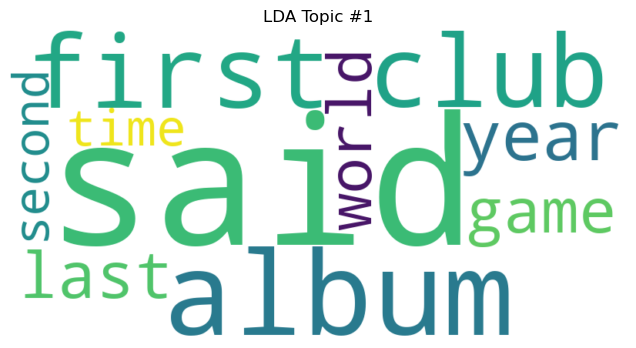

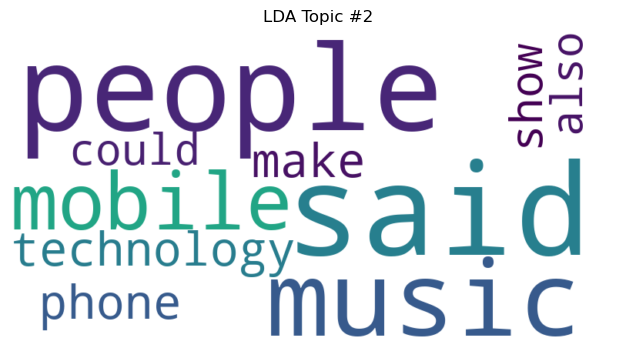

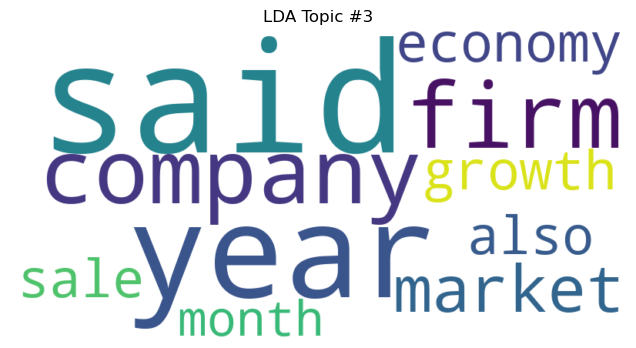

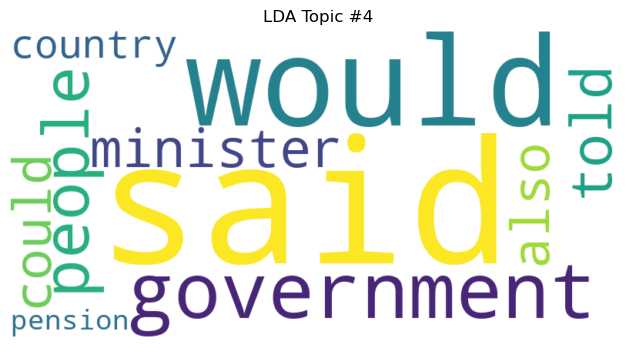

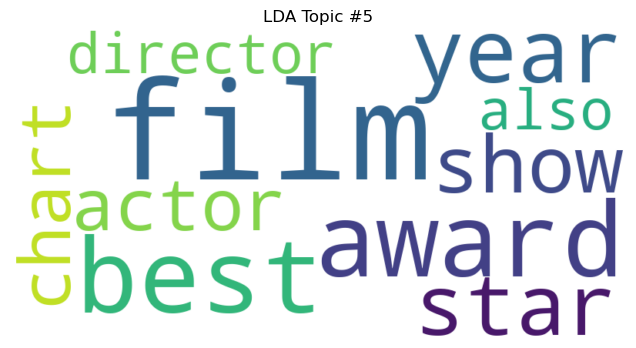

In [19]:
!pip install wordcloud --quiet
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# WordClouds for LDA Topics
print("📌 WordClouds for LDA Topics:")
for i, topic in lda_model.show_topics(num_topics=5, formatted=False):
    plt.figure(figsize=(8, 4))
    wordcloud = WordCloud(width=800, height=400, background_color='white')
    wordcloud.generate_from_frequencies(dict(topic))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"LDA Topic #{i+1}")
    plt.show()

📌 WordClouds for NMF Topics:


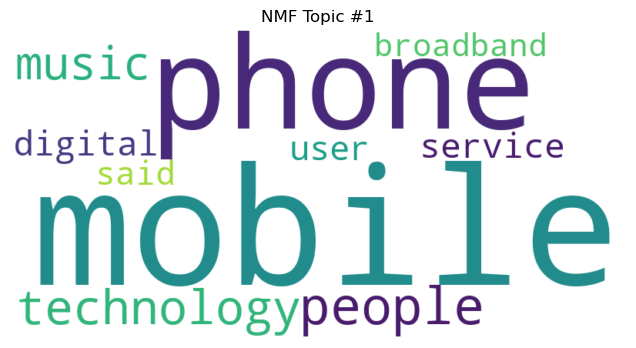

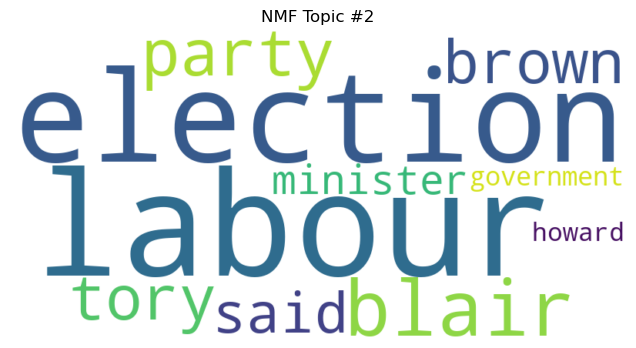

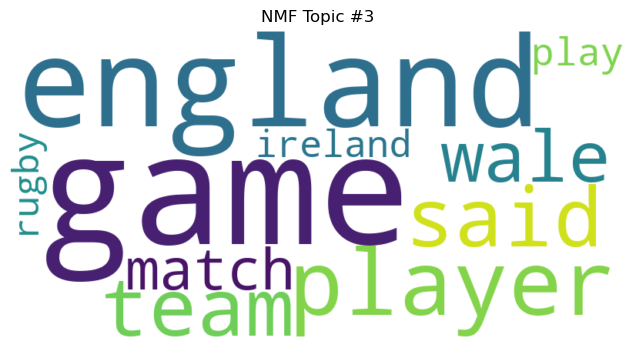

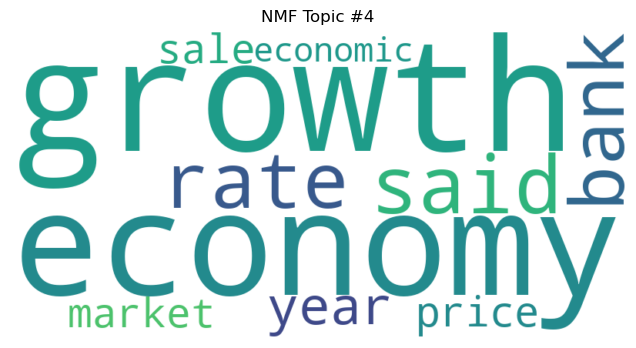

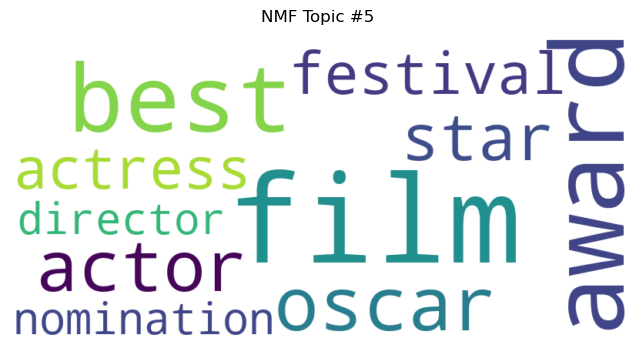

In [20]:
# WordClouds for NMF Topics
print("📌 WordClouds for NMF Topics:")
for idx, topic in enumerate(nmf_model.components_):
    top_words = {feature_names[i]: topic[i] for i in topic.argsort()[:-11:-1]}
    plt.figure(figsize=(8, 4))
    wordcloud = WordCloud(width=800, height=400, background_color='white')
    wordcloud.generate_from_frequencies(top_words)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"NMF Topic #{idx+1}")
    plt.show()

## 🤖 LDA vs NMF: Quick Summary
#### > 🎯Coherence Score: LDA – 47.88% | NMF – 74.23% 🚀
#### > 🧩Topic Quality: NMF = clearer, non-repetitive keywords
#### > 🥇Best Choice: NMF for clean and easy-to-understand topics